In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rudrakumargupta/comic-books-dataset-10000-entries/comic_books_10000_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rudrakumargupta/comic-books-dataset-10000-entries/comic_books_10000_dataset.csv")
df

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.0,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.3,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13
3,CMC-00004,Abyss Destiny,Yuna Yamaguchi,Yuna Yamaguchi,Kodansha (Kodansha USA),2014,Manga Volume,Black & White,Slice of Life / Drama,Japan,592,8.7,Cancelled,Japanese,Teen+,Eisner Award Nominee,13
4,CMC-00005,After Smoke,Shannon Watters,Warren Ellis,Kodansha Comics,2005,OGN,Black & White,Romance / Drama,USA,2465,7.0,Ongoing,English,Mature,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CMC-09996,Forsaken Reincarnation,Kai Yoshida,Kai Yoshida,Leed-sha,2019,Single Issue / Tankobon,Black & White,Psychological / Thriller,Japan,4143,7.9,Ongoing,Japanese,Young Adult,NaN,15
9996,CMC-09997,Lion Memory,Daisuke Imai,Mitsuru Adachi,Ichijinsha,2019,Manga Volume,Black & White,School / Romance,Japan,2987,8.3,Hiatus,Japanese,Teen+,NaN,45
9997,CMC-09998,Legendary F-Ranked Void System,Nam Hyun-jun,Go Chan,Kakao Webtoon,2017,Digital Webtoon,Full Color / Limited Palette,Reincarnation / Fantasy,South Korea,1548,6.9,Ongoing,Korean,Mature,NaN,13
9998,CMC-09999,The Lost Gold,Noelle Stevenson,Faith Erin Hicks,Drawn & Quarterly,2023,Omnibus,Black & White,Adventure / Comedy,New Zealand,1758,7.2,Completed,English,Mature,NaN,8


In [4]:
df.shape


(10000, 17)

In [5]:
df = pd.read_csv("/kaggle/input/datasets/rudrakumargupta/comic-books-dataset-10000-entries/comic_books_10000_dataset.csv",header=None,usecols=[10,11,16])
df.columns = ['Page Count',' Rating (out of 10)	',' Volume Count']

In [6]:
print(df)

       Page Count  Rating (out of 10)\t  Volume Count
0      Page Count    Rating (out of 10)  Volume Count
1             890                   8.0            13
2            2850                   8.3            12
3             350                   7.8            13
4             592                   8.7            13
...           ...                   ...           ...
9996         4143                   7.9            15
9997         2987                   8.3            45
9998         1548                   6.9            13
9999         1758                   7.2             8
10000        3710                   8.0            13

[10001 rows x 3 columns]


In [7]:
df.columns = df.columns.str.strip()

<Axes: xlabel='Volume Count', ylabel='count'>

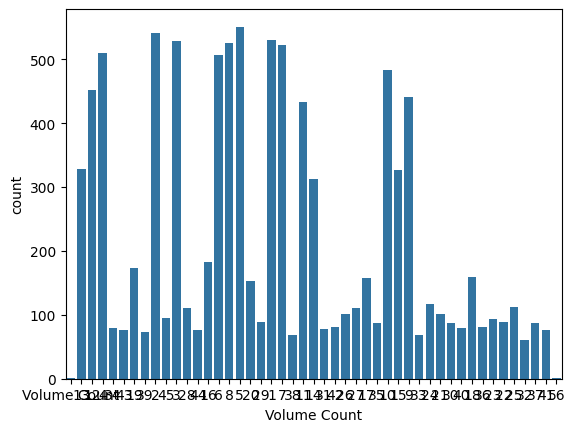

In [8]:
sns.countplot(x=df['Volume Count'])

<Axes: xlabel='Page Count', ylabel='count'>

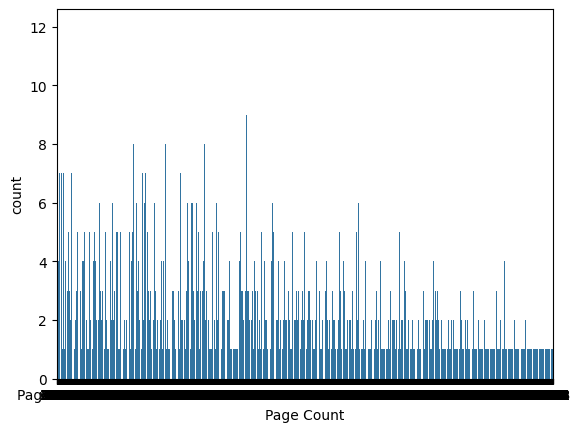

In [9]:
sns.countplot(x=df['Page Count'])

In [10]:
df.columns = df.columns.str.strip()

<Axes: xlabel='Page Count', ylabel='Rating (out of 10)'>

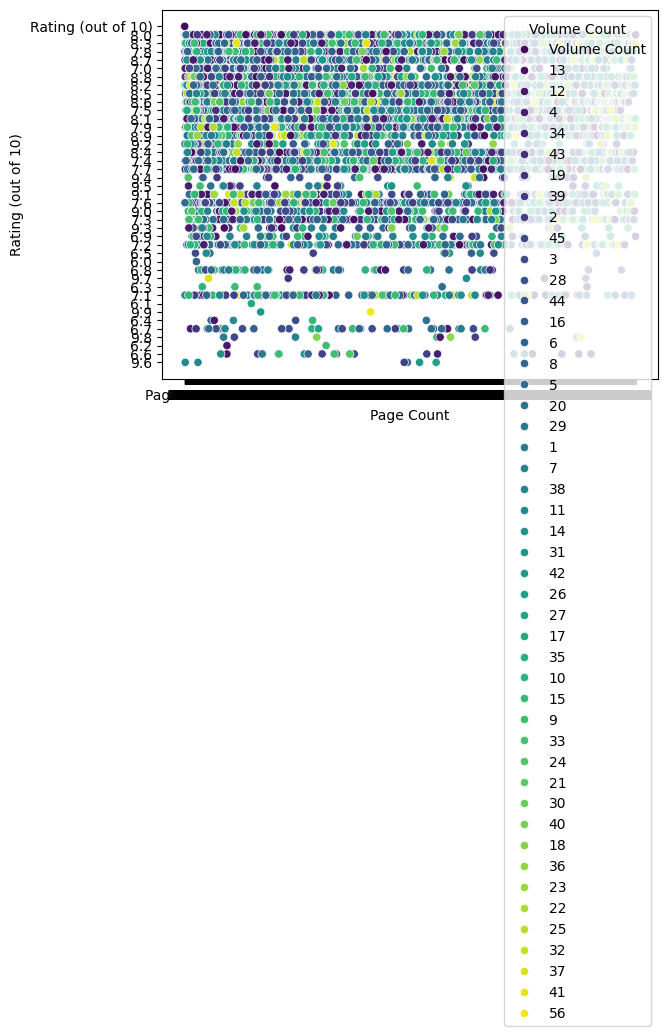

In [11]:
sns. scatterplot(
    data=df,
    x='Page Count',
    y='Rating (out of 10)',
    hue='Volume Count',
    palette='viridis'
)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
import pandas as pd

df['Volume Count'] = pd.to_numeric(df['Volume Count'],errors='coerce')

df = df.dropna()

df =df[df['Volume Count'] !=16]

In [14]:
from sklearn.model_selection import train_test_split

X = df[['Volume Count']]   # double brackets (DataFrame)
y = df['Rating (out of 10)']   # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0
)

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
y = y.ravel()

/tmp/ipykernel_16/294074625.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()


In [17]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [18]:
np.round(X_train.describe(),1)

,Volume Count
count,6872.0
mean,13.6
std,11.4
min,1.0
25%,5.0
50%,10.0
75%,19.0
max,45.0


In [19]:
np.round(X_train_scaled.describe(),1)

,Volume Count
count,6872.0
mean,0.3
std,0.3
min,0.0
25%,0.1
50%,0.2
75%,0.4
max,1.0


In [20]:
print(df.head())

  Page Count Rating (out of 10)  Volume Count
1        890                8.0          13.0
2       2850                8.3          12.0
3        350                7.8          13.0
4        592                8.7          13.0
5       2465                7.0           4.0


In [21]:
df.columns = df.columns.str.strip()

In [22]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [23]:
print(type(X_train_scaled))
print(X_train_scaled.shape)
print(X_train.columns)

<class 'pandas.core.frame.DataFrame'>
(6872, 1)
Index(['Volume Count'], dtype='object')


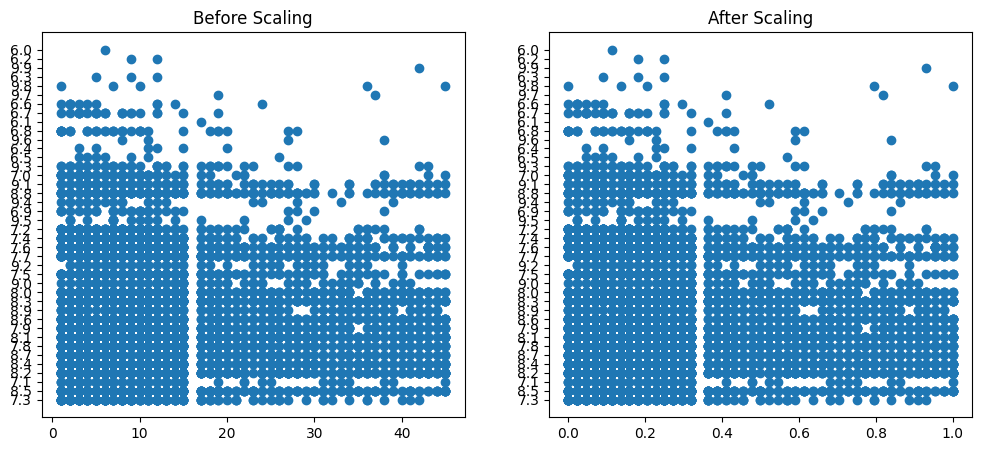

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Volume Count'], y_train)
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['Volume Count'], y_train)
ax2.set_title("After Scaling")

plt.show()

In [25]:
print(df.columns)

Index(['Page Count', 'Rating (out of 10)', 'Volume Count'], dtype='object')


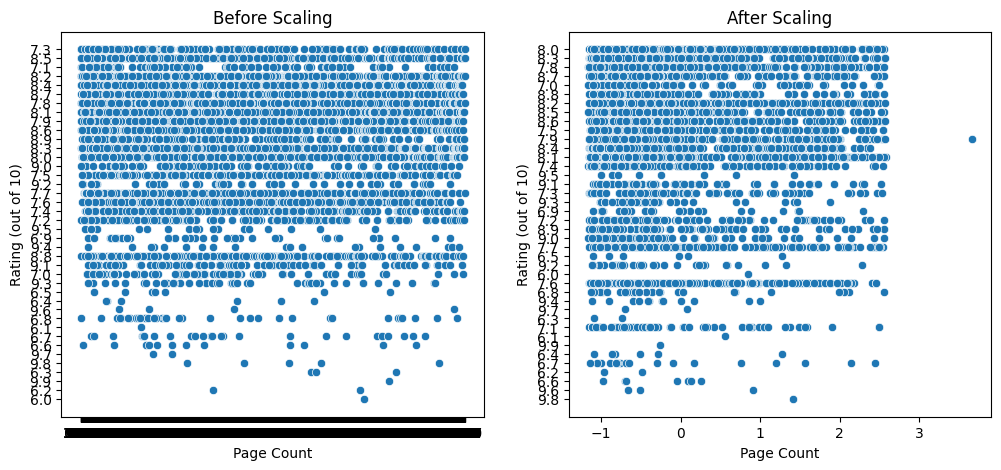

In [26]:
X = df[['Page Count']]   # NOT Volume Count
y = df['Rating (out of 10)']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.scatterplot(x=X_train['Page Count'], y=y_train, ax=ax1)
ax1.set_title("Before Scaling")

sns.scatterplot(x=X_train_scaled['Page Count'], y=y_train, ax=ax2)
ax2.set_title("After Scaling")

plt.show()